# Generate TestSet Questions to evaluate your RAG pipeline

> Tech Stack: [LangGraph](https://github.com/langchain-ai/langchain), [Qdrant](https://github.com/qdrant/qdrant), [OpenAI](https://platform.openai.com/) and [TruLens](https://github.com/truera/trulens)

> TruLens benchmark to generate the questions

### Installation

In [72]:
!pip install langgraph langchain-community langchain-openai langchain-qdrant
!pip install trulens "trulens-benchmark"

In [71]:
!pip install trulens-providers-openai

## Initial Setup

Install the required libraries and configure API keys for OpenAI and Qdrant. A TruLens session is initialized here to track and store all evaluation data throughout the notebook.

- Get OpenAI API Key: [https://platform.openai.com/](https://platform.openai.com/)
- Get Qdrant API Key and Endpoint URL: [https://cloud.qdrant.io/](https://cloud.qdrant.io/)

In [1]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
QDRANT_URL = userdata.get("QDRANT_URL")
QDRANT_API_KEY = userdata.get("QDRANT_API_KEY")

### Overview

We will generate a dataset to evaluate the RAG pipeline built using LangGraph and Qdrant, and assess it using the RAG Triad evaluation metrics.

In [3]:
from langchain_community.document_loaders import PyPDFium2Loader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient, models

In [4]:
from trulens.core import TruSession

session = TruSession()
session.reset_database()

🦑 Initialized with db url sqlite:///default.sqlite .
🛑 Secret keys may be written to the database. See the `database_redact_keys` option of `TruSession` to prevent this.
✅ experimental Feature.OTEL_TRACING enabled.
🔒 experimental Feature.OTEL_TRACING is enabled and cannot be changed.


Updating app_name and app_version in apps table: 0it [00:00, ?it/s]
Updating app_id in records table: 0it [00:00, ?it/s]
Updating app_json in apps table: 0it [00:00, ?it/s]


## Data loading and chunking

The Economic Survey 2025-26 report is downloaded and parsed using PyPDFium2. It is then split into overlapping chunks using Langchain's RecursiveCharacterTextSplitter to prepare the text for embedding and retrieval.

> Economic Survey 2025-26 by Government of India: [Survey Report](https://www.indiabudget.gov.in/economicsurvey/doc/eschapter/epreface.pdf)

In [15]:
!curl -L -A "Mozilla/5.0" https://www.indiabudget.gov.in/economicsurvey/doc/eschapter/epreface.pdf -o survey.pdf

In [59]:
path = "survey.pdf"
loader = PyPDFium2Loader(path)
docs = loader.load()

In [16]:
print(len(docs))

In [17]:
print(docs[1].page_content)

In [18]:
print(docs[1].metadata)

In [15]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1536,
    chunk_overlap = 0,
)
chunks = text_splitter.split_documents(docs)

## Setup your Qdrant Vector Database

A Qdrant collection is configured using dense vectors generated from OpenAI embeddings, enabling semantic search based on meaning and contextual similarity. Each document or chunk is converted into its corresponding embedding and indexed within the collection along with its associated metadata.

During retrieval, the query is embedded into the same vector space and matched against the indexed vectors to return the most semantically relevant results.

In [5]:
embeddings_model = OpenAIEmbeddings(model="text-embedding-3-small")

In [6]:
print(len(embeddings_model.embed_query("this is testing to check dimensions")))

1536


In [7]:
collection_name = "economic"

In [8]:
client = QdrantClient(
    url=QDRANT_URL,
    api_key=QDRANT_API_KEY
)

In [14]:
client.create_collection(
    collection_name = collection_name,
    vectors_config = {
        "dense" : models.VectorParams(
            size = 1536,
            distance = models.Distance.COSINE
        )
    }
)

In [9]:
db = QdrantVectorStore(
    client = client,
    collection_name = collection_name,
    embedding = embeddings_model,
    vector_name ="dense",
)

### Test the retriver

In [14]:
db.add_documents(documents=chunks) # just run it once. After the data is indexed, you need not have to add_documents again

In [10]:
query = "what is Financial Time wrote on the eve of Christmas 2025"
relevant_docs = db.max_marginal_relevance_search(query)

In [11]:
relevant_docs[0].page_content

'ix\nremains integrated yet increasingly distrustful. One could attach a subjective probability of \naround 40% to 45% to this scenario unfolding in 2026. Reflecting this is the Global Economic\nPolicy Uncertainty Index2\n, which is near its worst readings of 2020, excluding the sharp spike\nin April 2025 at the introduction of the reciprocal tariffs. Fear lingers. That brings us to the\nsecond scenario.\nIn this scenario, the probability of a disorderly multipolar breakdown rises materially\nand cannot be treated as a tail risk. Under this outcome, strategic rivalry intensifies, the\nRussia–Ukraine conflict remains unresolved in a destabilising form, and collective security\narrangements unravel. Trade becomes increasingly explicitly coercive, sanctions and counter\ufffemeasures proliferate, supply chains are realigned under political pressure, and financial\nstress events are transmitted across borders with fewer buffers and weaker institutional shock\nabsorbers. In this world, polic

> Convert to the retriever: i.e., Langchain object

In [12]:
retriever = db.as_retriever()

In [13]:
print(retriever.invoke(query)[0].page_content)

ix
remains integrated yet increasingly distrustful. One could attach a subjective probability of 
around 40% to 45% to this scenario unfolding in 2026. Reflecting this is the Global Economic
Policy Uncertainty Index2
, which is near its worst readings of 2020, excluding the sharp spike
in April 2025 at the introduction of the reciprocal tariffs. Fear lingers. That brings us to the
second scenario.
In this scenario, the probability of a disorderly multipolar breakdown rises materially
and cannot be treated as a tail risk. Under this outcome, strategic rivalry intensifies, the
Russia–Ukraine conflict remains unresolved in a destabilising form, and collective security
arrangements unravel. Trade becomes increasingly explicitly coercive, sanctions and counter￾measures proliferate, supply chains are realigned under political pressure, and financial
stress events are transmitted across borders with fewer buffers and weaker institutional shock
absorbers. In this world, policy becomes more nat

## Build your LangGraph RAG workflow - Answer Generation

In [19]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

In [20]:
llm = ChatOpenAI(model_name="gpt-5-mini")

In [21]:
SYSTEM_PROMPT = """
  You are an expert financial analyst specializing in corporate finance.
  You should be respectful and truthful while answering the user questions, if not you will face serious consequences.

  The only source information you have is the context provided, if the user query is not from the context
  Just say `I dont know , not enough information provided.`
"""

In [22]:
USER_PROMPT = """
  Answer the USER QUERY based on the CONTEXT below.
  If the question cannot be answered using the information provided answer with `I dont know , not enough information provided.`

  <context>
  CONTEXT: {context}
  </context>

  <query>
  USER QUERY: {query}
  </query>
"""

In [23]:
from langgraph.graph import StateGraph # node and edges logic
from langgraph.graph import START,END
from typing import TypedDict, List

In [24]:
class RAGState(TypedDict):
    query: str
    context: List[str]
    answer: str

In [25]:
def search(state: RAGState) -> RAGState:
    relevant_docs = retriever.invoke(state['query'])

    context = []
    for doc in relevant_docs:
        context.append(doc.page_content)

    state['context'] = context
    return state

In [26]:
def answer(state: RAGState) -> RAGState:
    context = " ".join(state['context'])

    prompt_template = ChatPromptTemplate(
        messages = [
            ("system",SYSTEM_PROMPT),
            ("user",USER_PROMPT.format(context=context,
                                        query=state['query']))
        ],
    )
    answer = llm.invoke(prompt_template.format_messages())
    state['answer'] = answer.content
    return state

In [27]:
# Agent - workflows
workflow = StateGraph(RAGState)
workflow.add_node("search_context",search)
workflow.add_node("answer_generation",answer)

workflow.add_edge(START,"search_context")
workflow.add_edge("search_context","answer_generation")
workflow.add_edge("answer_generation",END)

graph = workflow.compile()

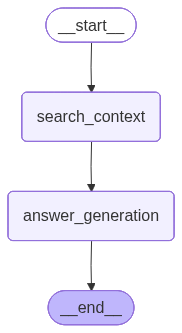

In [28]:
graph

In [29]:
def execute_graph(question: str) -> str:
    result = graph.invoke({"query": question})
    return result["answer"]

In [30]:
print(execute_graph(query))

On the eve of Christmas 2025, the Financial Times wrote, “Tech companies have moved more than $120bn of data centre spending off their balance sheets using special purpose rates, and the market’s growing assessment of geopolitical and financial tail risks.


## Generate Testset using TruLens

TruLens allows you to generate a test set of a specified breadth and depth, tailored to your app and data. The resulting test set will be a list of test prompts of length depth, for breadth categories of prompts. This test set will be made up of breadth X depth prompts organized by prompt category.

In [47]:
from trulens.providers.openai import OpenAI
from trulens.benchmark.generate.generate_test_set import GenerateTestSet

In [36]:
test = GenerateTestSet(app_callable = execute_graph)
provider = OpenAI()

In [ ]:
test_set = test.generate_test_set(
    test_breadth=3,
    test_depth=2,
)

# breadth = 3 → generate 3 categories
# depth = 2 → generate 2 questions

In [39]:
test_set

{'Economic Growth': ['According to the Survey, what is the revised estimate of India’s potential growth rate and how does it compare to the estimate three years ago?',
  'Which infrastructure developments does the Survey cite as easing logistics constraints and raising economy‑wide efficiency?'],
 'Fiscal Stability': ['According to the Survey, what shift underpins India’s current fiscal credibility?',
  'What state-level fiscal concerns does the chapter on fiscal developments highlight as risks to fiscal stability?'],
 'Institutional Capacity': ['According to the context, what are the core components or key dimensions of state (institutional) capacity?',
  'How does the context describe the role of regulatory capacity and process reforms in strengthening institutional capacity and national resilience?']}

## Run Evals

Evaluate with TruLens feedbacks

In [63]:
import numpy as np
from trulens.core import Metric
from trulens.core import Selector
from trulens.core import Feedback
from trulens.apps.app import TruApp

In [65]:
f_groundedness = Metric(
    implementation=provider.groundedness_measure_with_cot_reasons_consider_answerability,
    name="Groundedness",
    selectors={
        "source": Selector.select_context(collect_list=True),
        "statement": Selector.select_record_output(),
        "question": Selector.select_record_input(),
    },
)
f_answer_relevance = Metric(
    implementation=provider.relevance_with_cot_reasons,
    name="Answer Relevance",
    selectors={
        "prompt": Selector.select_record_input(),
        "response": Selector.select_record_output(),
    },
)

f_context_relevance = Metric(
    implementation=provider.context_relevance_with_cot_reasons,
    name="Context Relevance",
    selectors={
        "question": Selector.select_record_input(),
        "context": Selector.select_context(collect_list=False),
    }
)

In [66]:
tru_app = TruApp(
    execute_graph,
    app_name="IndiaEconRAG",
    app_version="v1",
    feedbacks=[f_groundedness, f_answer_relevance, f_context_relevance]
)

In [67]:
results = {}

with tru_app as recording:
    for topic, questions in test_set.items():
        results[topic] = []
        for question in questions:
            answer = execute_graph(question)  # recorded by TruLens AND stored in results
            results[topic].append({
                "question": question,
                "answer": answer
            })

In [70]:
results

{'Economic Growth': [{'question': 'According to the Survey, what is the revised estimate of India’s potential growth rate and how does it compare to the estimate three years ago?',
   'answer': 'The Survey revises India’s potential growth rate to 7.0%, up from 6.5% three years ago — a 0.5 percentage-point increase.'},
  {'question': 'Which infrastructure developments does the Survey cite as easing logistics constraints and raising economy‑wide efficiency?',
   'answer': 'It cites the expansion of infrastructure, specifically the doubling of the airport network over the past decade and the rapid growth of freight movement through inland waterways.'}],
 'Fiscal Stability': [{'question': 'According to the Survey, what shift underpins India’s current fiscal credibility?',
   'answer': 'The Survey says India’s fiscal credibility rests on a deliberate shift toward capital formation and human‑capital investment, supported by stronger revenue mobilisation and expenditure‑quality reforms.'},
  